In [2]:

import torch, torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# transforms:  3×32×32 RGB  →  flat 3072-vector in [0,1]
to_flat = T.Compose([
    T.ToTensor(),                       # [3,32,32], float32 ∈ [0,1]
    T.Lambda(lambda x: x.view(-1))      # flatten to [3072]
])

# full CIFAR-10 training set  (50 000 images)
cifar10 = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=to_flat
)
    
train_frac   = 0.90
total         = len(cifar10)                    # 60 000
train_size   = int(total * train_frac)      # 12 000
torch.manual_seed(0)                          #seed
rdid = torch.randperm(total)
train_idx = rdid[:train_size]
test_idx  = rdid[train_size:]
cifar10_train  = Subset(cifar10, train_idx)
cifar10_test  = Subset(cifar10, test_idx)

# feature dimension  
D = 3*32*32     # 3072


def show_all_imgs_grid(all_imgs, rows=5, cols=None, figsize=None):
    total = len(all_imgs)
    if cols is None:
        cols = (total + rows - 1) // rows
    if total == 0:
        print("No images to display.")
        return

    if figsize is None:
        # Adjust figsize to match image count (e.g., 3x3 images → (9, 9))
        figsize = (cols * 2, rows * 2)

    fig, axs = plt.subplots(rows, cols, figsize=figsize)

    if rows == 1 and cols == 1:
        axs = [[axs]]
    elif rows == 1:
        axs = [axs]
    elif cols == 1:
        axs = [[ax] for ax in axs]

    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axs[r][c]
        if i < total:
            ax.imshow(all_imgs[i])
            ax.axis("off")
            ax.set_aspect('equal')  # prevent stretched spacing
        else:
            ax.remove()


Files already downloaded and verified


In [3]:
import torch, torch.nn as nn, torch.nn.functional as F

### Training Transformer Implementation


class WitnessScoreCrossAttention(nn.Module):
    """
    ∇ log q_t(x) for a batch of B items, each with C query vectors.
    Shapes
    -------
      x : [B, C, D]
      W : [K, D]   (learnable witnesses, fp32 parameter)
      t : scalar  or  [B, C] tensor   (broadcastable to [B, C, 1])
      return  score : [B, C, D]
    """
    def __init__(self, init_W: torch.Tensor):          # init_W float32 [K,D]
        super().__init__()
        self.register_buffer("W", init_W.float())          # keep FP32 for stable grads

    
    @staticmethod
    def _pairwise_scores(x, tx, kernel='std'):
        """
        Exact KDE score where keys == values == queries (self-attention).
        x : [B,C,D]   t : broadcastable to [B,C,1]
        returns score_self : [B,C,D]
        """
        # different tx for context and for query
        C = x.shape[1]
        # squared norms
        x2 = (x**2).sum(-1, keepdim=True)           # [B,C,1]
        # pairwise dot-products   -> [B,C,C]
        dot = torch.matmul(x, x.transpose(-1, -2))
        # pairwise squared distances
        dist2 = - 2*dot  # [B,C,C]
        if kernel=='rbf':
            dist2 = dist2 + x2 + x2.transpose(-2, -1) 

        
        w = torch.softmax(-0.5 * dist2 * tx[None,:,None], dim=-1) # [B,C,C]

        mask = torch.eye(w.shape[1], dtype=torch.bool, device=w.device).unsqueeze(0)
        w = w.masked_fill(mask, float(0.0))

        expX = torch.matmul(w, x)                   # [B,C,D]

        return -(x - expX) *tx[None,:,None]

    def forward(self, x, tW, tx, kernel='std'):
        B, C, D = x.shape
        W = self.W.to(x.dtype)                         # fp16/bf16 copy  [K,D]

        # --- squared‐norm terms 
        x2 = (x**2).sum(dim=-1, keepdim=True)          # [B, C, 1]
        W2 = (W**2).sum(dim=-1)                        # [K]

        # --- cross term  x·Wᵀ  -> matmul broadcasts over B and C 
        #result shape [B, C, K]
        cross = torch.matmul(x, W.T)                   # (B,C,D)·(D,K)

        # --- pairwise squared distances 
        dist2 = x2 + W2.view(1, 1, -1) - 2 * cross     # [B, C, K]

        # --- time tensor broadcast to [B,C,1] 
        assert (tW.dim() == 1)
        assert tx.dim() == 1 and tx.shape[0]==C, tx.shape

        # --- attention weights, expectation of W 
        w    = torch.softmax(-0.5 * dist2 * tW[None,:,None], dim=-1)       # [B,C,K]
        expW = torch.matmul(w, W)                            # [B,C,D]

        # --- score 
        W_score = -(x - expW) *tW[None,:,None]                         # [B,C,D]
        x_score = self._pairwise_scores(x, tx, kernel)
        return (W_score, x_score)

def init_witnesses(train_tensor: torch.Tensor,
                   K: int = 1000,
                   seed: int | None = None) -> torch.Tensor:
    """
    Initialise K witness vectors by sampling K distinct examples
    from the dataset (no replacement).

    Args
    ----
    train_tensor : [N, D] float32 – flattened training images
    K            : number of witnesses
    seed         : optional RNG seed for reproducibility

    Returns
    -------
    W0 : [K, D] float32  (clone of the selected rows)
    """
    if seed is not None:
        torch.manual_seed(seed)

    N = train_tensor.size(0)
    if K > N:
        raise ValueError(f"K={K} exceeds dataset size N={N}")

    # sample K unique indices without replacement
    idx = torch.randperm(N, device=train_tensor.device)[:K]

    # gather the corresponding data points
    W0 = train_tensor[idx].clone()          # [K, D]
    return W0.float()                       # ensure fp32



class LStepDenoiser_multiple(nn.Module):
    def __init__(self, L, K, witness_tensor, t_start=1.0, t_end=0.1, kernel='std'):
        super().__init__()

        # 3a. six independent witness layers
        self.scores = nn.ModuleList([
            WitnessScoreCrossAttention(witness_tensor)
            for i in range(L)
        ])
        self.kernel=kernel
        
        # 3b. schedule parameters (unchanged)
        t_lin  = torch.linspace(t_start, t_end, L)
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:]-t_lin[-2:-1]])/2
        self.tW_raw  = nn.Parameter(torch.log(torch.exp(1/t_lin)  - 1)[:,None].repeat((1,2)).detach())
        self.dtW_raw = nn.Parameter(torch.log(torch.exp(-dt_lin) - 1)[:,None].repeat((1,2)).detach())
            
        self.tx_raw  = nn.Parameter(torch.log(torch.exp(1/t_lin).detach()  - 1)[:,None].repeat((1,2)).detach())
        self.dtx_raw = nn.Parameter(torch.log(torch.exp(-dt_lin).detach() - 1)[:,None].repeat((1,2)).detach())

        self.do_ICL = True

    def times_and_steps(self):
        tW  = F.softplus(self.tW_raw)
        dtW = -F.softplus(self.dtW_raw)
        tx  = F.softplus(self.tx_raw)
        dtx = -F.softplus(self.dtx_raw)
        return tW, dtW, tx, dtx

    def forward(self, x0, first_layer=0):
        tW, dtW, tx, dtx = self.times_and_steps()
        C = x0.shape[1]
        x = x0; traj=[x.clone()]
        L = len(self.scores)
        for i in range(first_layer, L):
            dtW_vec = torch.cat((dtW[i,0].repeat(C-1), dtW[i,1].repeat(1))).to(device)
            tW_vec = torch.cat((tW[i,0].repeat(C-1), tW[i,1].repeat(1))).to(device)
            dtx_vec = torch.cat((dtx[i,0].repeat(C-1), dtx[i,1].repeat(1))).to(device)
            tx_vec = torch.cat((tx[i,0].repeat(C-1), tx[i,1].repeat(1))).to(device)

            W_score, x_score = self.scores[i](x, tW_vec, tx_vec, self.kernel)       # layer-specific witnesses
            x = x - dtW_vec[None,:,None] * W_score
            if self.do_ICL:
                x = x - dtx_vec[None,:,None] * x_score
            traj.append(x.clone())
        return x, traj


=== ctx = baseline | epochs = 2 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx1_ep2_noise5.0_ts1.5_te0.02.pt
→ RMSE = 42.5809

=== ctx = 2 | epochs = 3 ===


/home/users/par55/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Saved weights to ./mnist_denoiser_ckpts/mnist_ctx2_ep3_noise5.0_ts1.5_te0.02.pt
→ RMSE = 14.2504

=== ctx = 4 | epochs = 4 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx4_ep4_noise5.0_ts1.5_te0.02.pt
→ RMSE = 12.6595

=== ctx = 28 | epochs = 6 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx28_ep6_noise5.0_ts1.5_te0.02.pt
→ RMSE = 10.1912

=== ctx = 42 | epochs = 7 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx42_ep7_noise5.0_ts1.5_te0.02.pt
→ RMSE = 10.2411

=== ctx = 56 | epochs = 7 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx56_ep7_noise5.0_ts1.5_te0.02.pt
→ RMSE = 9.7187

=== ctx = 63 | epochs = 7 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx63_ep7_noise5.0_ts1.5_te0.02.pt
→ RMSE = 10.4075

=== ctx = 84 | epochs = 8 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx84_ep8_noise5.0_ts1.5_te0.02.pt
→ RMSE = 10.1016

=== ctx = 105 | epochs = 8 ===
Saved weights to ./mnist_denoiser_ckpts/mnist_ctx105_ep8_noise5.0_ts1.5_te0.02.pt
→ RMSE = 9.3566


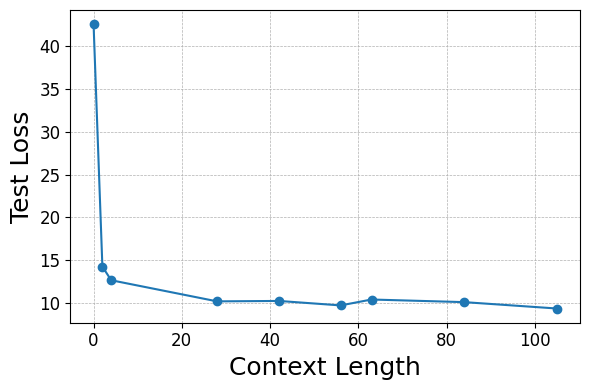

In [3]:
#  MNIST RMSE vs. N_CONTEXT 



import torch, torchvision, math, gc, os
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Sampler

#  Hyper-parameters 
Layers             = 6
NOISE_STD, K_WIT   = 5.0, 1000
t_start, t_end     = 1.5, 0.02
GLOBAL_BATCH       = 5040
DTYPE              = torch.float16
device             = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True
rng                = torch.Generator().manual_seed(1234)


CKPT_DIR = './mnist_denoiser_ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)

#  Epoch schedule
BASE_EPOCHS, EPOCHS_SCALE = 15, 10
epochs_for_ctx = lambda c: BASE_EPOCHS if c <= 1 else int(BASE_EPOCHS + EPOCHS_SCALE*math.log2(c))

#  Dataset (once, fp16) 
flat = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Lambda(lambda x: x.view(-1))
])
mnist = torchvision.datasets.MNIST('./data', train=True, download=True, transform=flat)

imgs   = torch.stack([x for x, _ in mnist]).to(device).to(DTYPE)
labels = torch.tensor([y for _, y in mnist], device=device, dtype=torch.long)
D      = imgs.shape[1]

split = int(0.9 * len(imgs))
train_imgs, test_imgs     = imgs[:split],  imgs[split:]
train_labels, test_labels = labels[:split], labels[split:]
train_set = TensorDataset(train_imgs, train_labels)
test_set  = TensorDataset(test_imgs,  test_labels)
WITNESS_TENSOR = train_imgs                       # fp16 on-GPU

#  Same-class sampler 
class FastSameClassSampler(Sampler):
    def __init__(self, labels: torch.Tensor, ctx: int, shuffle=True):
        self.labels, self.ctx, self.shuffle = labels.cpu(), ctx, shuffle
        self.batch  = GLOBAL_BATCH
        self.steps  = len(self.labels) // self.batch
        cls  = torch.unique(self.labels).tolist()
        self.bucket = {c: torch.where(self.labels == c)[0] for c in cls}
        self._build()

    def _build(self):
        chunks = []
        for idx in self.bucket.values():
            if self.shuffle:
                idx = idx[torch.randperm(len(idx), generator=rng)]
            usable = idx[: (len(idx) // self.ctx) * self.ctx]
            chunks.append(usable.reshape(-1, self.ctx))
        all_chunks = torch.cat(chunks)
        if self.shuffle:
            all_chunks = all_chunks[torch.randperm(len(all_chunks), generator=rng)]
        self.idx = all_chunks.flatten()[: self.steps * self.batch]

    def __iter__(self):
        if self.shuffle:
            self._build()
        for b in range(self.steps):
            s = b * GLOBAL_BATCH
            yield self.idx[s : s + GLOBAL_BATCH].tolist()

    def __len__(self):
        return self.steps

#  Loader builder 
def make_loaders(n_context: int):
    ctx = max(n_context, 1)
    if GLOBAL_BATCH % ctx:
        raise ValueError("GLOBAL_BATCH not divisible by N_CONTEXT")
    if ctx == 1:
        tl = DataLoader(train_set, batch_size=GLOBAL_BATCH, shuffle=True, drop_last=True)
    else:
        tl = DataLoader(train_set, batch_sampler=FastSameClassSampler(train_labels, ctx))
    vl = DataLoader(test_set,  batch_sampler=FastSameClassSampler(test_labels, ctx))
    return tl, vl, ctx

#  Train + eval (token-0, per-image RMSE) 
def train_and_eval(n_context: int):
    tl, vl, ctx = make_loaders(n_context)
    EPOCHS = epochs_for_ctx(ctx)

    model = LStepDenoiser_multiple(
        L=Layers, K=K_WIT, witness_tensor=WITNESS_TENSOR,
        t_start=t_start, t_end=t_end, kernel='rbf'
    ).to(device)
    model.do_ICL = (n_context > 0)

    ckpt = f'{CKPT_DIR}/mnist_ctx{ctx}_ep{EPOCHS}_noise{NOISE_STD}_ts{t_start}_te{t_end}.pt'

    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f'Loaded weights from {ckpt}')
    else:
        opt     = torch.optim.Adam(model.parameters(), lr=5e-2, betas=(0.9, 0.9))
        scaler  = torch.cuda.amp.GradScaler()
        sched   = torch.optim.lr_scheduler.CosineAnnealingLR(
                      opt, T_max=EPOCHS * len(tl), eta_min=1e-3)

        for _ in range(EPOCHS):
            for clean, _ in tl:
                clean = clean.reshape(-1, ctx, D).to(device, dtype=DTYPE)

                noisy = clean.clone()
                noisy[:, 0, :] += torch.randn_like(clean[:, 0, :]) * NOISE_STD  # noise token 0 only

                with torch.cuda.amp.autocast(dtype=DTYPE):
                    recon, _ = model(noisy)
                    mse = (recon[:, 0, :] - clean[:, 0, :]).pow(2).mean()       # per-pixel MSE

                opt.zero_grad(set_to_none=True)
                scaler.scale(mse).backward()
                scaler.step(opt); scaler.update(); sched.step()

        torch.save(model.state_dict(), ckpt)
        print(f'Saved weights to {ckpt}')

    # ── Evaluation ──  (per-image RMSE, token 0)
    model.eval(); se_sum = n_img = 0
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=DTYPE):
        for clean, _ in vl:
            clean = clean.reshape(-1, ctx, D).to(device, dtype=DTYPE)
            noisy = clean.clone()
            noisy[:, 0, :] += torch.randn_like(clean[:, 0, :]) * NOISE_STD
            recon, _ = model(noisy)

            se_sum += (recon[:, 0, :] - clean[:, 0, :]).pow(2).sum().item()  # Σ ‖·‖²
            n_img  += clean.size(0)

    rmse = math.sqrt(se_sum / n_img)      # ← per-image RMSE (×√D vs old version)
    del model; torch.cuda.empty_cache(); gc.collect()
    return rmse

#  Sweep 
contexts = [0, 2, 4, 28, 42, 56, 63, 84, 105]
rmse_vals = []
for ctx in contexts:
    print(f'\n=== ctx = {ctx or "baseline"} | epochs = {epochs_for_ctx(max(ctx,1))} ===')
    rmse = train_and_eval(ctx)
    rmse_vals.append(rmse)
    print(f'→ RMSE = {rmse:.4f}')

#  Plot 
AXIS_FONT_SIZE = 18
LABEL_FONT_SIZE = 12
TITLE_FONT_SIZE = 24 


plt.figure(figsize=(6, 4))
plt.plot(contexts, rmse_vals, marker='o')

plt.xlabel('Context Length', fontsize=AXIS_FONT_SIZE)
plt.ylabel('Test Loss',                                    fontsize=AXIS_FONT_SIZE)
#plt.title('MNIST: N_CONTEXT vs Test Loss',           fontsize=TITLE_FONT_SIZE)

plt.xticks(fontsize=LABEL_FONT_SIZE)
plt.yticks(fontsize=LABEL_FONT_SIZE)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [3]:
# CIFAR-10 token-0 denoiser 

import os, math, gc, torch, torchvision, matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Sampler

# Hyper-parameters
Layers             = 6
NOISE_STD          = 2.0
t_start, t_end     = 1.5, 0.02
GLOBAL_BATCH       = 2400
DTYPE              = torch.float16
device             = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True
rng                = torch.Generator().manual_seed(1234)

BASE_EPOCHS, EPOCHS_SCALE = 15, 25
# User-editable per-context epoch overrides (takes longer for them to converge)
EPOCH_MAP = {1: 15, 2: 40, 8: 90, 16: 115, 32: 140, 60: 500}
def epochs_for_ctx(c):
    return EPOCH_MAP.get(c, BASE_EPOCHS if c <= 1 else int(BASE_EPOCHS + EPOCHS_SCALE*math.log2(c)))

CKPT_DIR = './cifar10_denoiser_ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)

#  Dataset cache 
if 'CIFAR_CACHE' not in globals():
    tfm  = torchvision.transforms.Compose([
               torchvision.transforms.ToTensor(),
               torchvision.transforms.Lambda(lambda x: x.view(-1))])
    cif  = torchvision.datasets.CIFAR10('./data', train=True,
                                        download=True, transform=tfm)
    imgs_cifar   = torch.stack([x for x,_ in cif]).to(device).to(DTYPE)
    labels_cifar = torch.tensor([y for _,y in cif], device=device, dtype=torch.long)
    D_CIFAR      = imgs_cifar.shape[1]                     # 3072

    split        = int(0.9 * len(imgs_cifar))
    train_imgs_c, test_imgs_c     = imgs_cifar[:split], imgs_cifar[split:]
    train_lbls_c, test_lbls_c     = labels_cifar[:split], labels_cifar[split:]
    TRAIN_SET_CIFAR = TensorDataset(train_imgs_c, train_lbls_c)
    TEST_SET_CIFAR  = TensorDataset(test_imgs_c,  test_lbls_c)
    WITNESS_CIFAR   = train_imgs_c                      # full dataset

    CIFAR_CACHE = True  # marker

#  Fast same-class sampler
class FastSameClassSampler(Sampler):
    def __init__(self, labels: torch.Tensor, ctx: int, shuffle=True):
        self.labels, self.ctx, self.shuffle = labels.cpu(), ctx, shuffle
        self.batch  = GLOBAL_BATCH
        self.steps  = len(self.labels) // self.batch
        cls = torch.unique(self.labels).tolist()
        self.bucket = {c: torch.where(self.labels == c)[0] for c in cls}
        self._build()

    def _build(self):
        blocks=[]
        for idx in self.bucket.values():
            if self.shuffle:
                idx = idx[torch.randperm(len(idx), generator=rng)]
            usable = idx[: (len(idx)//self.ctx)*self.ctx]
            blocks.append(usable.reshape(-1, self.ctx))
        all_blocks = torch.cat(blocks)
        if self.shuffle:
            all_blocks = all_blocks[torch.randperm(len(all_blocks), generator=rng)]
        self.idx = all_blocks.flatten()[: self.steps * self.batch]

    def __iter__(self):
        if self.shuffle:
            self._build()
        for b in range(self.steps):
            s = b * GLOBAL_BATCH
            yield self.idx[s : s + GLOBAL_BATCH].tolist()

    def __len__(self):
        return self.steps

def make_loaders(n_context:int):
    ctx = max(n_context, 1)
    if GLOBAL_BATCH % ctx:
        raise ValueError("GLOBAL_BATCH not divisible by N_CONTEXT")
    if ctx == 1:
        tl = DataLoader(TRAIN_SET_CIFAR, batch_size=GLOBAL_BATCH,
                        shuffle=True, drop_last=True)
    else:
        tl = DataLoader(
            TRAIN_SET_CIFAR,
            batch_sampler=FastSameClassSampler(TRAIN_SET_CIFAR.tensors[1], ctx))
    vl = DataLoader(
        TEST_SET_CIFAR,
        batch_sampler=FastSameClassSampler(TEST_SET_CIFAR.tensors[1], ctx))
    return tl, vl, ctx

#  Train + eval with slim ckpts 
def _strip_witness(state_dict):
    """Remove the 50 000×3072 witness buffers before saving."""
    return {k:v for k,v in state_dict.items() if '.W' not in k}

def train_and_eval(n_context:int) -> float:
    tl, vl, ctx = make_loaders(n_context)
    EPOCHS = epochs_for_ctx(ctx)

    ckpt = f'{CKPT_DIR}/cifar_ctx{ctx}_ep{EPOCHS}_noise{NOISE_STD}.pt'

    model = LStepDenoiser_multiple(
        L=Layers, K=WITNESS_CIFAR.size(0), witness_tensor=WITNESS_CIFAR,
        t_start=t_start, t_end=t_end, kernel='rbf').to(device)
    model.do_ICL = (n_context > 0)

    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=device), strict=False)
        print(f'Loaded slim schedule from {ckpt}')
    else:
        opt=torch.optim.Adam(model.parameters(), lr=5e-2, betas=(0.9,0.9))
        scaler=torch.cuda.amp.GradScaler()
        sched=torch.optim.lr_scheduler.CosineAnnealingLR(
                  opt, T_max=EPOCHS*len(tl), eta_min=1e-3)

        for _ in range(EPOCHS):
            for clean,_ in tl:
                clean = clean.reshape(-1, ctx, D_CIFAR).to(device, dtype=DTYPE)
                noisy = clean.clone()
                noisy[:,0,:] += torch.randn_like(clean[:,0,:]) * NOISE_STD
                with torch.cuda.amp.autocast(dtype=DTYPE):
                    recon,_ = model(noisy)
                    # ── per-image MSE (sum over pixels, mean over batch) ──
                    mse = (recon[:,0,:] - clean[:,0,:]).pow(2).sum(dim=1).mean()
                opt.zero_grad(set_to_none=True)
                scaler.scale(mse).backward()
                scaler.step(opt); scaler.update(); sched.step()
        torch.save(_strip_witness(model.state_dict()), ckpt)
        print(f'Saved slim schedule to {ckpt}')

    # ── Evaluation ──
    model.eval(); se_sum = n_img = 0
    with torch.no_grad(), torch.cuda.amp.autocast(dtype=DTYPE):
        for clean,_ in vl:
            clean = clean.reshape(-1, ctx, D_CIFAR).to(device, dtype=DTYPE)
            noisy = clean.clone()
            noisy[:,0,:] += torch.randn_like(clean[:,0,:]) * NOISE_STD
            recon,_ = model(noisy)
            se_sum += (recon[:,0,:] - clean[:,0,:]).pow(2).sum().item()   # Σ ‖·‖²
            n_img  += clean.size(0)
    rmse = math.sqrt(se_sum / n_img)        # per-image RMSE
    del model; torch.cuda.empty_cache(); gc.collect()
    return rmse

#  Sweep 
contexts = [0, 2, 8, 16, 32, 60]
rmse_vals=[]
for ctx in contexts:
    print(f'\n=== ctx = {ctx or "baseline"} | epochs = {epochs_for_ctx(max(ctx,1))} ===')
    rmse = train_and_eval(ctx)
    rmse_vals.append(rmse)
    print(f'→ RMSE = {rmse:.4f}')


#  Plot
AXIS_FONT_SIZE = 18
LABEL_FONT_SIZE = 12
TITLE_FONT_SIZE = 24 


plt.figure(figsize=(6, 4))
plt.plot(contexts, rmse_vals, marker='o')

plt.xlabel('Context Length', fontsize=AXIS_FONT_SIZE)
plt.ylabel('Test Loss',                                    fontsize=AXIS_FONT_SIZE)
#plt.title('CIFAR-10: N_CONTEXT vs Test Loss',           fontsize=TITLE_FONT_SIZE)

plt.xticks(fontsize=LABEL_FONT_SIZE)
plt.yticks(fontsize=LABEL_FONT_SIZE)

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()




Files already downloaded and verified

=== ctx = baseline | epochs = 15 ===


/home/users/par55/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Saved slim schedule to ./cifar10_denoiser_ckpts/cifar_ctx1_ep15_noise2.0.pt
→ RMSE = 12.0184

=== ctx = 2 | epochs = 40 ===
Saved slim schedule to ./cifar10_denoiser_ckpts/cifar_ctx2_ep40_noise2.0.pt
→ RMSE = 11.0782

=== ctx = 8 | epochs = 90 ===
Saved slim schedule to ./cifar10_denoiser_ckpts/cifar_ctx8_ep90_noise2.0.pt
→ RMSE = 17.3135

=== ctx = 16 | epochs = 115 ===


KeyboardInterrupt: 

In [4]:
##helper – rebuild & load a trained MNIST denoiser
def load_mnist_model(ctx: int,
                     *,
                     Layers: int = 6,
                     K_WIT: int = 1000,
                     t_start: float = 1.5,
                     t_end:   float = 0.02,
                     noise_std: float = 5.0,
                     ckpt_dir: str = './mnist_denoiser_ckpts'):
    """
    Returns a `LStepDenoiser_multiple` initialised with the correct
    witness tensor, schedule and weights for the given `ctx`.
    Raises FileNotFoundError if the checkpoint is missing.
    """
    #  make sure globals exist (created in the earlier MNIST cell) 
    global WITNESS_TENSOR, DTYPE, device, epochs_for_ctx   # noqa: F401
    if 'WITNESS_TENSOR' not in globals():
        raise RuntimeError("WITNESS_TENSOR not in scope – run the MNIST "
                           "dataset cell first.")
    EPOCHS = epochs_for_ctx(max(ctx, 1))

    ckpt = (f'{ckpt_dir}/mnist_ctx{ctx}_ep{EPOCHS}_'
            f'noise{noise_std}_ts{t_start}_te{t_end}.pt')
    if not os.path.exists(ckpt):
        raise FileNotFoundError(f'Checkpoint not found: {ckpt}\n'
                                '→ Run the MNIST training sweep first.')

    model = LStepDenoiser_multiple(
        L=Layers, K=K_WIT, witness_tensor=WITNESS_TENSOR,
        t_start=t_start, t_end=t_end, kernel="rbf"
    ).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.do_ICL = (ctx > 0)
    model.eval()
    return model


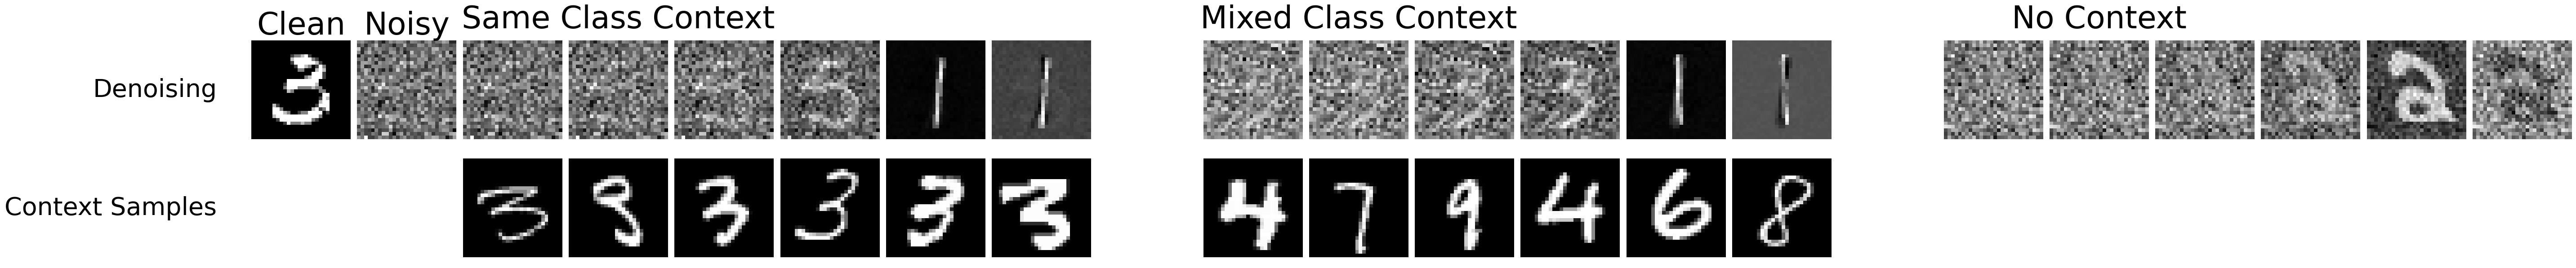

In [7]:
# Figure 6 plot
"""
Top row   : Clean | Noisy | 6× denoise (single-digit ctx) | ␣ | 6× denoise (mixed ctx)
                       | ␣ | 6× denoise (no ctx)

Bottom row: blank  | blank | 6 ctx imgs (single-digit) | ␣ | 6 ctx imgs (mixed)
                       | ␣ | blank

Row labels and group titles included.  Fonts ≈ 40 pt.  Blank “separator”
columns provide visual spacing between the three model blocks.
"""
import os, math, random, torch, matplotlib.pyplot as plt

#  parameters 
CTX_BIG               = 105          # training context length
LAYERS_MNIST          = 6           # denoising steps
NOISE_STD_MNIST       = 5.0
CELL_SIZE_INCH        = 2.6
FONT_SIZE             = 40
ROW_LABEL_FONTSIZE    = 40
COL_TITLE_FONTSIZE    = 50
SHOW_GROUP_TITLES     = True
GROUP_TITLES          = ["Same Class Context", "Mixed Class Context", "No Context"]

# helpers & vars from earlier cells must still be in scope:
# • load_mnist_model  • WITNESS_TENSOR  • test_set / test_labels
# • D, DTYPE, device  • epochs_for_ctx_mnist

#  build models 
model_none = load_mnist_model(1)          # trained with ctx = 0
model_mix  = load_mnist_model(CTX_BIG)    # trained with ctx = CTX_BIG

#  sample one test image 
idx     = random.randint(0, len(test_set) - 1)
clean0  = test_set[idx][0]                 # CPU tensor [784]
label0  = test_set[idx][1].item()

#  context-block builder 
def build_block(kind: str):
    """
    kind ∈ {'same', 'mixed', 'none'}
    Returns: noisy_block, list(ctx_imgs), traj_list
    """
    if kind == "none":
        clean_blk = clean0.view(1, 1, D).to(device, dtype=DTYPE)
        noisy_blk = clean_blk.clone()
        noisy_blk[:, 0] += torch.randn_like(noisy_blk[:, 0]) * NOISE_STD_MNIST
        with torch.no_grad(), torch.cuda.amp.autocast(dtype=DTYPE):
            _, traj = model_none(noisy_blk)
        return noisy_blk, [], traj

    # choose context indices
    same_idx = torch.where(test_labels == label0)[0]
    diff_idx = torch.where(test_labels != label0)[0]
    pool     = same_idx[same_idx != idx] if kind == "same" else diff_idx
    sel_idx  = pool[torch.randperm(len(pool))[: CTX_BIG - 1]]
    ctx_imgs = [clean0] + [test_set[i][0] for i in sel_idx]       # CPU tensors

    clean_blk = torch.stack(ctx_imgs).reshape(1, CTX_BIG, D).to(device, dtype=DTYPE)
    noisy_blk = clean_blk.clone()
    noisy_blk[:, 0] += torch.randn_like(noisy_blk[:, 0]) * NOISE_STD_MNIST

    with torch.no_grad(), torch.cuda.amp.autocast(dtype=DTYPE):
        _, traj = model_mix(noisy_blk)
    return noisy_blk, ctx_imgs[1:], traj   # omit token-0 from ctx list

# build all three regimes
blk_same, ctx_same, traj_same = build_block("same")
blk_mix , ctx_mix , traj_mix  = build_block("mixed")
blk_none, _       , traj_none = build_block("none")

#  tensors for plotting 
vec_clean = clean0.cpu()
vec_noisy = blk_same[0, 0].cpu()           # identical noisy token everywhere

steps_same = [t[0, 0].cpu() for t in traj_same[1:]]
steps_mix  = [t[0, 0].cpu() for t in traj_mix [1:]]
steps_none = [t[0, 0].cpu() for t in traj_none[1:]]

ctx_show_same = ctx_same[: LAYERS_MNIST]   # limit to 6 images
ctx_show_mix  = ctx_mix [: LAYERS_MNIST]

# convert to 28×28 in [0,1]
def to_img(v: torch.Tensor):
    v = v.detach().cpu().float().view(28, 28)
    return (v - v.min()) / (v.max() - v.min() + 1e-8)

#  layout with separator columns 
SEP_COLS = 2                               # blank columns between model blocks
cols     = 2 + 3 * LAYERS_MNIST + SEP_COLS
rows     = 2
fig_w    = cols * CELL_SIZE_INCH
fig_h    = rows * CELL_SIZE_INCH * 1.15
plt.figure(figsize=(fig_w, fig_h))

# column index for start of each group  g ∈ {0,1,2}
col_offset = lambda g: 2 + g * (LAYERS_MNIST + 1)

# column 0–1 : clean & noisy
plt.subplot(rows, cols, 1)
plt.imshow(to_img(vec_clean), cmap="gray"); plt.axis("off")
plt.title("Clean", fontsize=COL_TITLE_FONTSIZE)

plt.subplot(rows, cols, 2)
plt.imshow(to_img(vec_noisy), cmap="gray"); plt.axis("off")
plt.title("Noisy", fontsize=COL_TITLE_FONTSIZE)

#  denoising trajectories (top row) 
for i in range(LAYERS_MNIST):
    # single-digit ctx
    plt.subplot(rows, cols, col_offset(0) + i + 1)
    plt.imshow(to_img(steps_same[i]), cmap="gray"); plt.axis("off")

    # mixed ctx
    plt.subplot(rows, cols, col_offset(1) + i + 1)
    plt.imshow(to_img(steps_mix[i]), cmap="gray"); plt.axis("off")

    # no ctx
    plt.subplot(rows, cols, col_offset(2) + i + 1)
    plt.imshow(to_img(steps_none[i]), cmap="gray"); plt.axis("off")

#  bottom row: context images (or blanks) 
# first two columns blank
for j in range(2):
    plt.subplot(rows, cols, cols + j + 1); plt.axis("off")

for i in range(LAYERS_MNIST):
    # same-digit context
    plt.subplot(rows, cols, cols + col_offset(0) + i + 1)
    plt.imshow(to_img(ctx_show_same[i]), cmap="gray"); plt.axis("off")

    # mixed context
    plt.subplot(rows, cols, cols + col_offset(1) + i + 1)
    plt.imshow(to_img(ctx_show_mix[i]), cmap="gray"); plt.axis("off")

# blanks under "no ctx"
for i in range(LAYERS_MNIST):
    plt.subplot(rows, cols, cols + col_offset(2) + i + 1)
    plt.axis("off")

#  separator columns (axis off) 
for sep in (col_offset(1) - 1, col_offset(2) - 1):
    for r in range(rows):
        plt.subplot(rows, cols, r * cols + sep + 1)
        plt.axis("off")

#  row labels 
plt.subplot(rows, cols, 1)
plt.text(-0.35, 0.5, "Denoising", fontsize=ROW_LABEL_FONTSIZE,
         ha="right", va="center", transform=plt.gca().transAxes)

plt.subplot(rows, cols, cols + 1)
plt.text(-0.35, 0.5, "Context Samples", fontsize=ROW_LABEL_FONTSIZE,
         ha="right", va="center", transform=plt.gca().transAxes)

#  group titles above each trajectory block 
if SHOW_GROUP_TITLES:
    for g, title in enumerate(GROUP_TITLES):
        ax = plt.subplot(rows, cols, col_offset(g) + 2)
        ax.set_title(title, fontsize=COL_TITLE_FONTSIZE, pad=20)

plt.subplots_adjust(wspace=0.25)          # extra whitespace between all cells
plt.tight_layout()
plt.show()
